## 5. Evaluation

Walk-forward comparison on the shared horizon-1-to-8 grid, against seasonal-naive and the
RBA's own published forecasts.

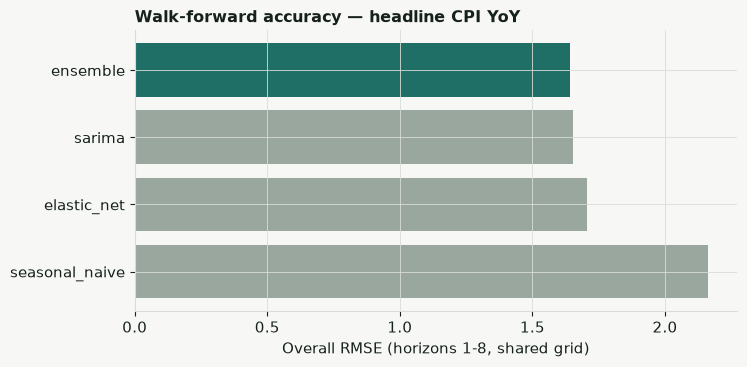

,model,n,rmse,mae
0,ensemble,424,1.640356,1.159850
1,sarima,424,1.652592,1.155351
2,elastic_net,424,1.705798,1.245831
3,seasonal_naive,424,2.163358,1.518632


In [48]:
comp = pd.read_csv(PROJECT_ROOT / "reports/model_comparison_all.csv")
overall = comp[comp["horizon"] == "overall"].sort_values("rmse")

fig, ax = plt.subplots(figsize=(7.6, 3.8))
colors = [ACCENT if m == "ensemble" else ("#9aa79f" if m != "rba" else HIGHLIGHT) for m in overall["model"]]
ax.barh(overall["model"], overall["rmse"], color=colors)
ax.invert_yaxis()
ax.set_xlabel("Overall RMSE (horizons 1-8, shared grid)")
ax.set_title("Walk-forward accuracy — headline CPI YoY", loc="left", fontsize=11.5, fontweight="bold")
fig.tight_layout()
plt.show()
overall[["model", "n", "rmse", "mae"]].reset_index(drop=True)

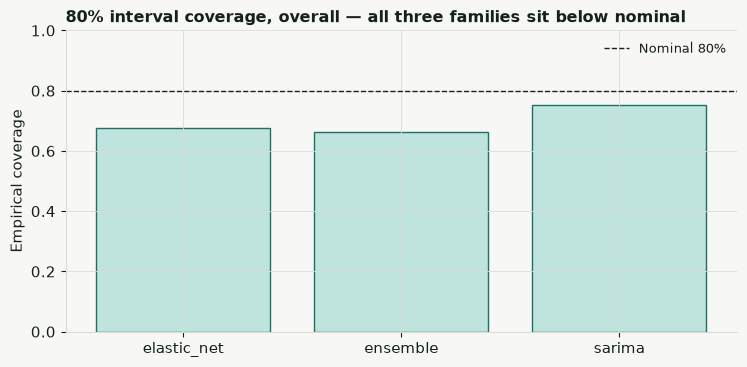

In [49]:
cov = pd.read_csv(PROJECT_ROOT / "reports/model_interval_coverage.csv")
cov_overall = (cov[cov["horizon"] == "overall"] if "overall" in cov["horizon"].astype(str).unique()
               else cov.groupby("model", as_index=False)["empirical_coverage"].mean())

fig, ax = plt.subplots(figsize=(7.6, 3.8))
ax.axhline(0.8, color=INK, linestyle="--", linewidth=1, label="Nominal 80%")
ax.bar(cov_overall["model"], cov_overall["empirical_coverage"], color=ACCENT_SOFT, edgecolor=ACCENT)
ax.set_ylim(0, 1)
ax.set_ylabel("Empirical coverage")
ax.set_title("80% interval coverage, overall — all three families sit below nominal",
             loc="left", fontsize=11.5, fontweight="bold")
ax.legend(frameon=False, fontsize=9)
fig.tight_layout()
plt.show()

Every family sits below its 80% nominal interval coverage — a known, tracked gap
(`reports/model_interval_coverage.csv`), not something this notebook papers over. SARIMA's
prediction intervals are closest to nominal; the Ensemble wins on point-forecast RMSE.